In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.chdir("../../..")

OPTIMIZED_PARAMS_DIR = "./Datasets/Generated/Optimized_Neural_Params"

# 1. Загрузка всех доступных CSV с оптимизированными параметрами

Сканируем папку, номер пропорции берём из имени файла `Optimized_Neural_Params(X).csv`.

In [2]:
files = []
for fname in os.listdir(OPTIMIZED_PARAMS_DIR):
    if fname.startswith("Optimized_Neural_Params(") and fname.endswith(".csv"):
        p = int(fname.split("(")[1].split(")")[0])
        files.append((p, os.path.join(OPTIMIZED_PARAMS_DIR, fname)))
files.sort(key=lambda x: x[0])
print(f"Найдено файлов: {len(files)}")
for p, path in files:
    print(f"  {p}: {os.path.basename(path)}")

Найдено файлов: 9
  10: Optimized_Neural_Params(10).csv
  30: Optimized_Neural_Params(30).csv
  50: Optimized_Neural_Params(50).csv
  70: Optimized_Neural_Params(70).csv
  75: Optimized_Neural_Params(75).csv
  80: Optimized_Neural_Params(80).csv
  85: Optimized_Neural_Params(85).csv
  90: Optimized_Neural_Params(90).csv
  95: Optimized_Neural_Params(95).csv


In [3]:
param_names = ["dend_gnabar_hh", "dend_gkbar_hh", "dend_gl_hh", "best_loss", "best_proportion"]
dfs = []
for proportion, path in files:
    d = pd.read_csv(path)
    d["proportion"] = proportion
    dfs.append(d[["proportion", "neuron_id"] + param_names].copy())
df = pd.concat(dfs, ignore_index=True)

df

,proportion,neuron_id,dend_gnabar_hh,dend_gkbar_hh,dend_gl_hh,best_loss,best_proportion
0,10,13726190,0.010948,0.066533,0.000151,10.333333,0.333333
1,10,10017661,0.012128,0.009094,0.002190,0.100000,0.000000
2,10,2777891,0.011856,0.143688,0.000837,0.009091,0.090909
3,10,17654973,0.017076,0.031114,0.004361,0.033333,0.066667
4,10,15998261,0.018763,0.090759,0.003537,0.001961,0.098039
...,...,...,...,...,...,...,...
34272,95,16594752,0.124621,0.115972,0.002695,0.063924,0.886076
34273,95,17913199,0.027841,0.049669,0.000052,0.002632,0.947368
34274,95,17360010,0.029182,0.023350,0.000116,0.010976,0.939024
34275,95,13081886,0.019758,0.007337,0.000235,0.000000,0.950000


# 2. Box plot: все параметры, все пропорции (одна картинка)

Один subplot на каждый параметр; на каждом — боксы по пропорциям, разный цвет для каждой пропорции.

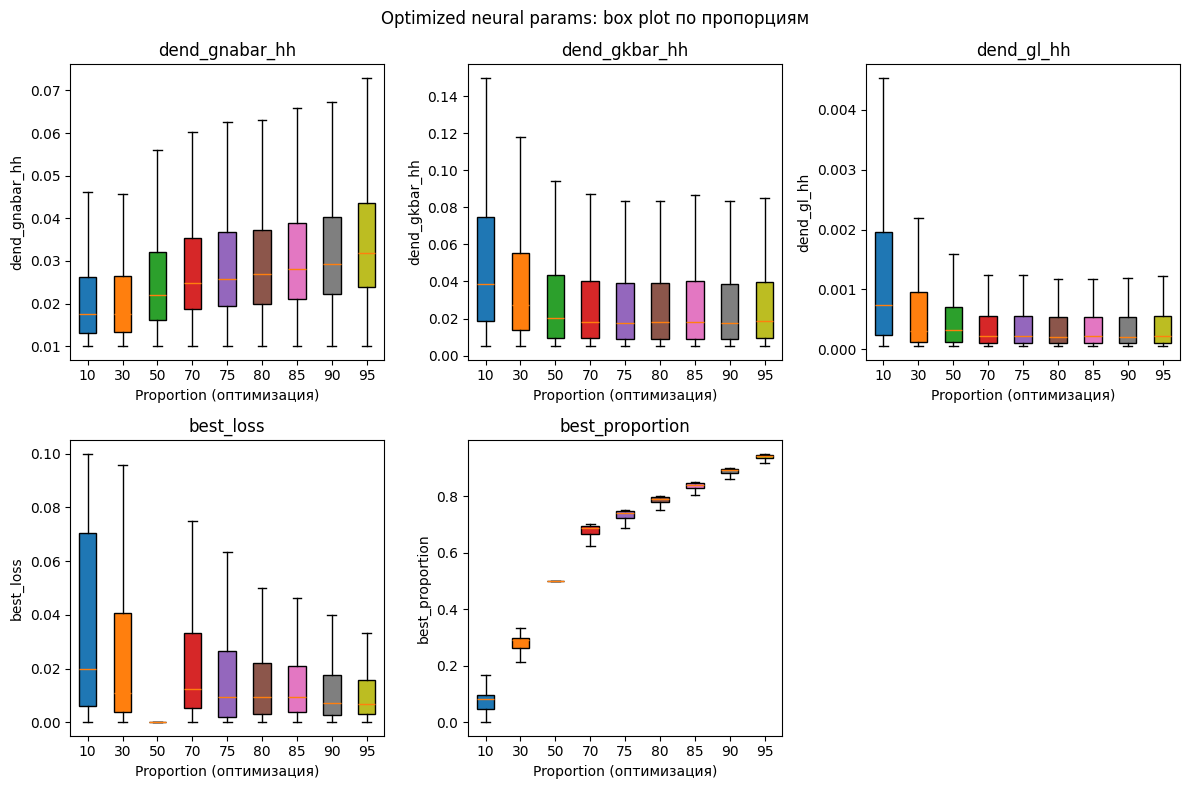

In [4]:
proportions = sorted(df["proportion"].unique())
n_prop = len(proportions)
colors = plt.cm.tab10(np.linspace(0, 1, max(n_prop, 10)))[:n_prop]
prop_to_color = {p: colors[i] for i, p in enumerate(proportions)}

n_params = len(param_names)
ncols = 3
nrows = (n_params + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes_flat = np.atleast_2d(axes).ravel()

for ax, param in zip(axes_flat, param_names):
    parts = ax.boxplot(
        [df.loc[df["proportion"] == prop, param].values for prop in proportions],
        positions=range(len(proportions)),
        tick_labels=[str(p) for p in proportions],
        patch_artist=True,
        showfliers=False,
    )
    for i, patch in enumerate(parts["boxes"]):
        patch.set_facecolor(prop_to_color[proportions[i]])
    ax.set_title(param)
    ax.set_xlabel("Proportion (оптимизация)")
    ax.set_ylabel(param)

for ax in axes_flat[n_params:]:
    ax.set_visible(False)

fig.suptitle("Optimized neural params: box plot по пропорциям", fontsize=12)
plt.tight_layout()
plt.show()

# 3. Сглаженные по Гауссу распределения (KDE) по одному subplot на параметр

Те же цвета для пропорций, что и на box plot.

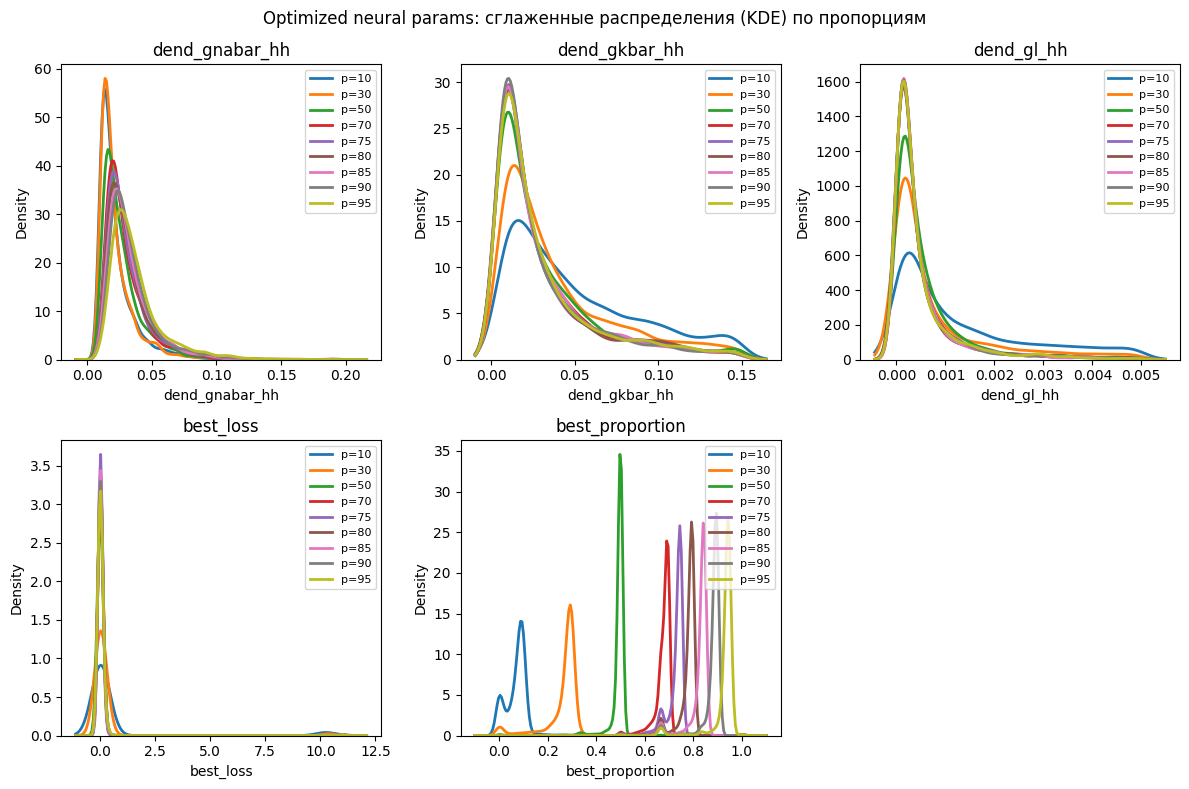

In [5]:
from scipy.stats import gaussian_kde

def smooth_pdf(values, x_grid, bw_method=None):
    """KDE (Gaussian smoothing) на сетке x_grid."""
    values = np.asarray(values).reshape(-1)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return np.zeros_like(x_grid)
    try:
        kde = gaussian_kde(values, bw_method=bw_method)
        return kde(x_grid)
    except np.linalg.LinAlgError:
        return np.zeros_like(x_grid)

n_params = len(param_names)
ncols = 3
nrows = (n_params + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes_flat = np.atleast_2d(axes).ravel()

for ax, param in zip(axes_flat, param_names):
    all_vals = df[param].dropna()
    x_min, x_max = all_vals.min(), all_vals.max()
    margin = (x_max - x_min) * 0.1 or 1e-6
    x_grid = np.linspace(x_min - margin, x_max + margin, 200)

    for prop in proportions:
        vals = df.loc[df["proportion"] == prop, param].values
        y = smooth_pdf(vals, x_grid)
        ax.plot(x_grid, y, color=prop_to_color[prop], label=f"p={prop}", lw=2)

    ax.set_title(param)
    ax.set_xlabel(param)
    ax.set_ylabel("Density")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylim(bottom=0)

for ax in axes_flat[n_params:]:
    ax.set_visible(False)

fig.suptitle("Optimized neural params: сглаженные распределения (KDE) по пропорциям", fontsize=12)
plt.tight_layout()
plt.show()